In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### **1. Imports and Reproducibility**

In [2]:
!pip install -q albumentations>=1.0.0
!pip install -q pycocotools

In [3]:
import os
import json
import math
import random
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models
import tensorflow.keras.backend as K
from pycocotools.coco import COCO
from pycocotools import mask as mask_utils
import albumentations as A
from sklearn.metrics import confusion_matrix

%matplotlib inline

# for reproducability
def set_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seeds(42)
print("Global random seeds set to 42 for strict reproducibility.")
print("TensorFlow version:", tf.__version__)

Global random seeds set to 42 for strict reproducibility.
TensorFlow version: 2.20.0


In [ ]:
!gdown --id '1QgR7ggu0CNFws1lqNsEcCGxeKRxjglNt' -O dataset.zip
!unzip -q dataset.zip -d .

os.remove("dataset.zip")
print("Dataset successfully downloaded and extracted!")

### **2. Configuration and Paths**

In [4]:
# Setup Paths
DATA_DIR = "RMDS_segmentation_dataset_ADE20K_350"
TRAIN_IMG_DIR = os.path.join(DATA_DIR, "train")
TRAIN_ANN_FILE = os.path.join(DATA_DIR, "instances_train.json")
VAL_IMG_DIR = os.path.join(DATA_DIR, "val")
VAL_ANN_FILE = os.path.join(DATA_DIR, "instances_val.json")
TEST_IMG_DIR = os.path.join(DATA_DIR, "test")

# Global Configuration
CONFIG = {
    "img_size": 128,
    "batch_size": 16,
    "epochs": 40,
    "learning_rate": 1e-3,
    "classes": ["background", "person", "car", "book", "airplane"],
    "num_classes": 5
}

# Visualization Mapping
CLASS_COLORS = {
    "background": (0, 0, 0, 0),
    "person": (1.0, 0.0, 0.0, 1.0),    # Red
    "car": (0.0, 1.0, 0.0, 1.0),       # Green
    "book": (1.0, 1.0, 0.0, 1.0),      # Yellow
    "airplane": (0.0, 0.0, 1.0, 1.0),  # Blue
}
CMAP = mcolors.ListedColormap([CLASS_COLORS[c] for c in CONFIG["classes"]])
NORM = mcolors.BoundaryNorm(np.arange(-0.5, CONFIG["num_classes"] + 0.5, 1), CMAP.N)

### **3. Custom Metrics (IoU & Dice)**

In [5]:
class MeanIoUMetric(tf.keras.metrics.Metric):
    def __init__(self, num_classes, name='mean_iou', **kwargs):
        super(MeanIoUMetric, self).__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.total_cm = self.add_weight(name='total_cm', shape=(num_classes, num_classes), initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(tf.reshape(y_true, tf.shape(y_pred)[:-1]), tf.int32)
        y_pred = tf.cast(tf.argmax(y_pred, axis=-1), tf.int32)

        cm = tf.math.confusion_matrix(tf.reshape(y_true, [-1]), tf.reshape(y_pred, [-1]),
                                      num_classes=self.num_classes, dtype=tf.float32)
        self.total_cm.assign_add(cm)

    def result(self):
        sum_over_row = tf.reduce_sum(self.total_cm, axis=0)
        sum_over_col = tf.reduce_sum(self.total_cm, axis=1)
        true_positives = tf.linalg.diag_part(self.total_cm)
        denominator = sum_over_row + sum_over_col - true_positives
        iou = tf.math.divide_no_nan(true_positives, denominator)
        return tf.reduce_mean(iou[1:])

    def reset_state(self):
        self.total_cm.assign(tf.zeros((self.num_classes, self.num_classes)))

class MeanDiceMetric(tf.keras.metrics.Metric):
    def __init__(self, num_classes, name='mean_dice', **kwargs):
        super(MeanDiceMetric, self).__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.intersection = self.add_weight(name='intersection', shape=(num_classes,), initializer='zeros')
        self.cardinality = self.add_weight(name='cardinality', shape=(num_classes,), initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(tf.reshape(y_true, tf.shape(y_pred)[:-1]), tf.int32)
        y_pred = tf.cast(tf.argmax(y_pred, axis=-1), tf.int32)

        y_true_onehot = tf.one_hot(y_true, self.num_classes)
        y_pred_onehot = tf.one_hot(y_pred, self.num_classes)

        self.intersection.assign_add(tf.reduce_sum(y_true_onehot * y_pred_onehot, axis=[0, 1, 2]))
        self.cardinality.assign_add(tf.reduce_sum(y_true_onehot + y_pred_onehot, axis=[0, 1, 2]))

    def result(self):
        dice = tf.math.divide_no_nan(2.0 * self.intersection, self.cardinality)
        return tf.reduce_mean(dice[1:])

    def reset_state(self):
        self.intersection.assign(tf.zeros((self.num_classes,)))
        self.cardinality.assign(tf.zeros((self.num_classes,)))

### **4. Loss Functions**

In [6]:
def categorical_focal_loss(alpha, gamma=2.0):
    alpha = tf.constant(alpha, dtype=tf.float32)
    def focal_loss_fn(y_true, y_pred):
        y_true = tf.cast(tf.reshape(y_true, tf.shape(y_pred)[:-1]), tf.int32)

        y_true_onehot = tf.one_hot(y_true, depth=len(alpha))
        y_pred = tf.clip_by_value(y_pred, K.epsilon(), 1.0 - K.epsilon())

        cross_entropy = -y_true_onehot * tf.math.log(y_pred)
        weight = tf.gather(alpha, y_true)
        focal_term = tf.math.pow(1.0 - y_pred, gamma)
        return tf.reduce_mean(weight * tf.reduce_sum(focal_term * cross_entropy, axis=-1))
    return focal_loss_fn

def foreground_dice_loss(num_classes):
    def dice_loss_fn(y_true, y_pred):
        y_true = tf.cast(tf.reshape(y_true, tf.shape(y_pred)[:-1]), tf.int32)

        y_true_onehot = tf.one_hot(y_true, depth=num_classes)
        y_true_fg = y_true_onehot[:, :, :, 1:]
        y_pred_fg = y_pred[:, :, :, 1:]

        intersection = tf.reduce_sum(y_true_fg * y_pred_fg, axis=[1, 2])
        union = tf.reduce_sum(y_true_fg + y_pred_fg, axis=[1, 2])
        dice_scores = tf.math.divide_no_nan(2.0 * intersection, union + K.epsilon())
        return 1.0 - tf.reduce_mean(dice_scores)
    return dice_loss_fn

def combined_focal_dice_loss(alpha, gamma=2.0, focal_weight=0.5, dice_weight=1.5):
    focal_fn = categorical_focal_loss(alpha, gamma)
    dice_fn = foreground_dice_loss(len(alpha))
    def loss_fn(y_true, y_pred):
        return focal_weight * focal_fn(y_true, y_pred) + dice_weight * dice_fn(y_true, y_pred)
    return loss_fn

### **5. Advanced Data Augmentation**

In [7]:
# Augmentation pipeline using albumentations
train_transform = A.Compose([
    A.RandomResizedCrop(size=(CONFIG["img_size"], CONFIG["img_size"]), scale=(0.4, 1.0), p=1.0),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=20, p=0.5),
])

val_transform = A.Compose([
    A.Resize(height=CONFIG["img_size"], width=CONFIG["img_size"], p=1.0)
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


### **6. Data Loading & Generator**

In [8]:
coco_train = COCO(TRAIN_ANN_FILE)
coco_val = COCO(VAL_ANN_FILE)
categories = coco_train.loadCats(coco_train.getCatIds())

def get_category_name(cat_id, cats):
    for cat in cats:
        if cat['id'] == cat_id: return cat['name']
    return None

class SegmentationGenerator(tf.keras.utils.Sequence):
    def __init__(self, img_dir, coco, img_ids, batch_size, is_training=False):
        self.img_dir = img_dir
        self.coco = coco
        self.img_ids = img_ids
        self.batch_size = batch_size
        self.is_training = is_training
        self.indexes = np.arange(len(self.img_ids))

        if self.is_training:
            np.random.shuffle(self.indexes)

    def __len__(self):
        return math.ceil(len(self.img_ids) / self.batch_size)

    def on_epoch_end(self):
        if self.is_training:
            np.random.shuffle(self.indexes)

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_ids = [self.img_ids[k] for k in batch_indexes]

        X = np.empty((len(batch_ids), CONFIG["img_size"], CONFIG["img_size"], 3), dtype=np.float32)
        Y = np.empty((len(batch_ids), CONFIG["img_size"], CONFIG["img_size"], 1), dtype=np.int32)

        for i, img_id in enumerate(batch_ids):
            img_info = self.coco.loadImgs(img_id)[0]
            img_path = os.path.join(self.img_dir, img_info['file_name'])
            raw_image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)

            # Generate the mask
            raw_mask = np.zeros((img_info['height'], img_info['width']), dtype=np.uint8)
            ann_ids = self.coco.getAnnIds(imgIds=img_info['id'])
            anns = self.coco.loadAnns(ann_ids)

            for ann in anns:
                cat_name = get_category_name(ann['category_id'], categories)
                if cat_name in CONFIG["classes"]:
                    class_idx = CONFIG["classes"].index(cat_name)
                    pixel_mask = self.coco.annToMask(ann)
                    raw_mask[pixel_mask > 0] = class_idx

            if self.is_training:
                augmented = train_transform(image=raw_image, mask=raw_mask)
            else:
                augmented = val_transform(image=raw_image, mask=raw_mask)

            X[i,] = augmented['image'] / 255.0
            Y[i,] = np.expand_dims(augmented['mask'], axis=-1)

        return X, Y

# Generators
train_ids = coco_train.getImgIds()
val_ids = coco_val.getImgIds()
train_gen = SegmentationGenerator(TRAIN_IMG_DIR, coco_train, train_ids, CONFIG["batch_size"], is_training=True)
val_gen = SegmentationGenerator(VAL_IMG_DIR, coco_val, val_ids, CONFIG["batch_size"], is_training=False)

loading annotations into memory...
Done (t=1.71s)
creating index...
index created!
loading annotations into memory...
Done (t=0.64s)
creating index...
index created!


### **7. EDA (Histograms & Pixel Distributions)**

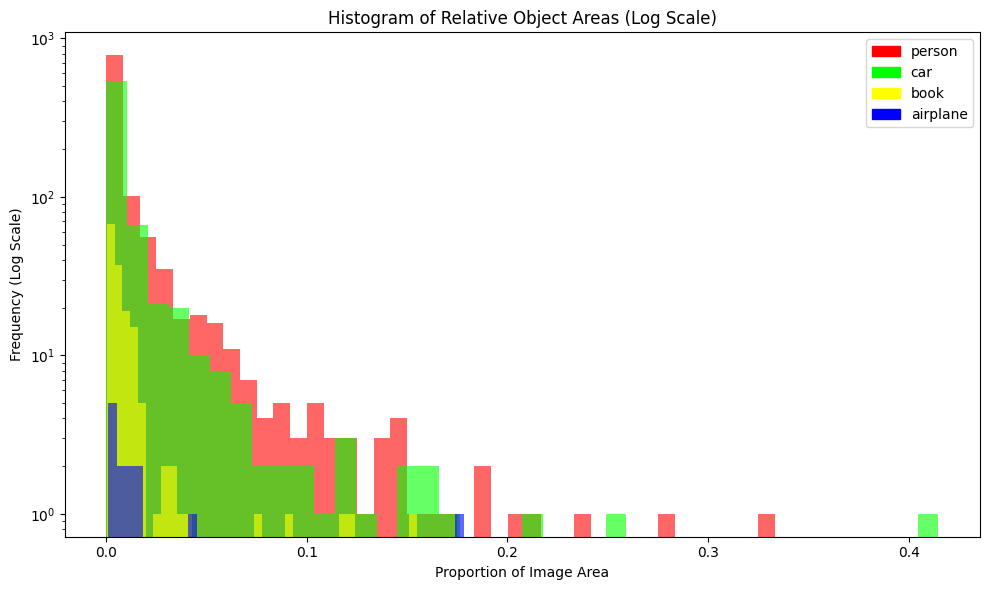

In [9]:
target_classes = CONFIG["classes"][1:]
object_areas = {c: [] for c in target_classes}

for img_id in train_ids:
    img = coco_train.loadImgs(img_id)[0]
    ann_ids = coco_train.getAnnIds(imgIds=img["id"])
    annotations = coco_train.loadAnns(ann_ids)
    for ann in annotations:
        cat_name = get_category_name(ann["category_id"], categories)
        if cat_name in target_classes:
            rel_area = ann["area"] / (img["height"] * img["width"])
            object_areas[cat_name].append(rel_area)

plt.figure(figsize=(10, 6))
for cat_name in target_classes:
    if object_areas[cat_name]:
        plt.hist(object_areas[cat_name], bins=40, alpha=0.6, label=cat_name, density=False, color=CLASS_COLORS[cat_name])

plt.title("Histogram of Relative Object Areas (Log Scale)")
plt.xlabel("Proportion of Image Area")
plt.ylabel("Frequency (Log Scale)")

plt.yscale('log')

handles = [plt.Rectangle((0, 0), 1, 1, color=CLASS_COLORS[c]) for c in CONFIG["classes"][1:]]
plt.legend(handles, CONFIG["classes"][1:])

plt.tight_layout()
plt.show()

### **8. Custom U-Net Architecture**

In [10]:
def conv_block(inputs, filters, dropout_rate=0.0):
    # use_bias=False because BatchNorm cancels out biases anyway
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)

    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    return x

def build_unet(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)

    c1 = conv_block(inputs, 32)
    p1 = layers.MaxPooling2D(2)(c1)
    c2 = conv_block(p1, 64)
    p2 = layers.MaxPooling2D(2)(c2)
    c3 = conv_block(p2, 128)
    p3 = layers.MaxPooling2D(2)(c3)
    c4 = conv_block(p3, 256, dropout_rate=0.3) # Added Dropout to prevent overfitting
    p4 = layers.MaxPooling2D(2)(c4)

    b = conv_block(p4, 512, dropout_rate=0.3)  # Added Dropout to the Bridge

    u4 = layers.Conv2DTranspose(256, 2, strides=2, padding="same")(b)
    u4 = layers.concatenate([u4, c4])
    c5 = conv_block(u4, 256)

    u3 = layers.Conv2DTranspose(128, 2, strides=2, padding="same")(c5)
    u3 = layers.concatenate([u3, c3])
    c6 = conv_block(u3, 128)

    u2 = layers.Conv2DTranspose(64, 2, strides=2, padding="same")(c6)
    u2 = layers.concatenate([u2, c2])
    c7 = conv_block(u2, 64)

    u1 = layers.Conv2DTranspose(32, 2, strides=2, padding="same")(c7)
    u1 = layers.concatenate([u1, c1])
    c8 = conv_block(u1, 32)

    outputs = layers.Conv2D(num_classes, 1, activation="softmax")(c8)
    return models.Model(inputs, outputs, name="Custom_UNet")

model = build_unet((CONFIG["img_size"], CONFIG["img_size"], 3), CONFIG["num_classes"])

### **9. Compilation & Callbacks**

In [11]:
class_weights_array = np.array([0.01, 20.0, 15.0, 45.0, 50.0], dtype=np.float32)
print("Aggressive Class Weights:", dict(zip(CONFIG["classes"], class_weights_array)))

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=CONFIG["learning_rate"]),
    loss=combined_focal_dice_loss(alpha=class_weights_array, gamma=2.0, focal_weight=0.5, dice_weight=1.5),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
        MeanIoUMetric(num_classes=CONFIG["num_classes"]),
        MeanDiceMetric(num_classes=CONFIG["num_classes"])
    ],
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        mode='min',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        mode='min',
        factor=0.5,
        patience=6,
        verbose=1,
        min_lr=1e-6
    )
]

Aggressive Class Weights: {'background': np.float32(0.01), 'person': np.float32(20.0), 'car': np.float32(15.0), 'book': np.float32(45.0), 'airplane': np.float32(50.0)}


### **10. Training Custom Model**

In [12]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=CONFIG["epochs"],
    callbacks=callbacks,
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 293s 12s/step - accuracy: 0.0488 - loss: 2.2996 - mean_dice: 0.0515 - mean_iou: 0.0271 - val_accuracy: 0.0015 - val_loss: 11.4090 - val_mean_dice: 0.0066 - val_mean_iou: 0.0033 - learning_rate: 0.0010
Epoch 2/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 447ms/step - accuracy: 0.0495 - loss: 1.8777 - mean_dice: 0.0513 - mean_iou: 0.0270 - val_accuracy: 0.0067 - val_loss: 2.4125 - val_mean_dice: 0.0289 - val_mean_iou: 0.0153 - learning_rate: 0.0010
Epoch 3/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 411ms/step - accuracy: 0.0499 - loss: 1.8475 - mean_dice: 0.0584 - mean_iou: 0.0309 - val_accuracy: 0.0077 - val_loss: 3.6973 - val_mean_dice: 0.0348 - val_mean_iou: 0.0186 - learning_rate: 0.0010
Epoch 4/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 410ms/step - accuracy: 0.0501 - loss: 1.8941 - mean_dice: 0.0571 - mean_iou: 0.0301 - val_accuracy: 0.0051 - val_loss: 12.1952 - val_mean_dice: 0.0060 - val_mean_iou: 0.0030 - learning_rate: 0.0010
Epoch 5/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 45

### **11. Training Analytics**

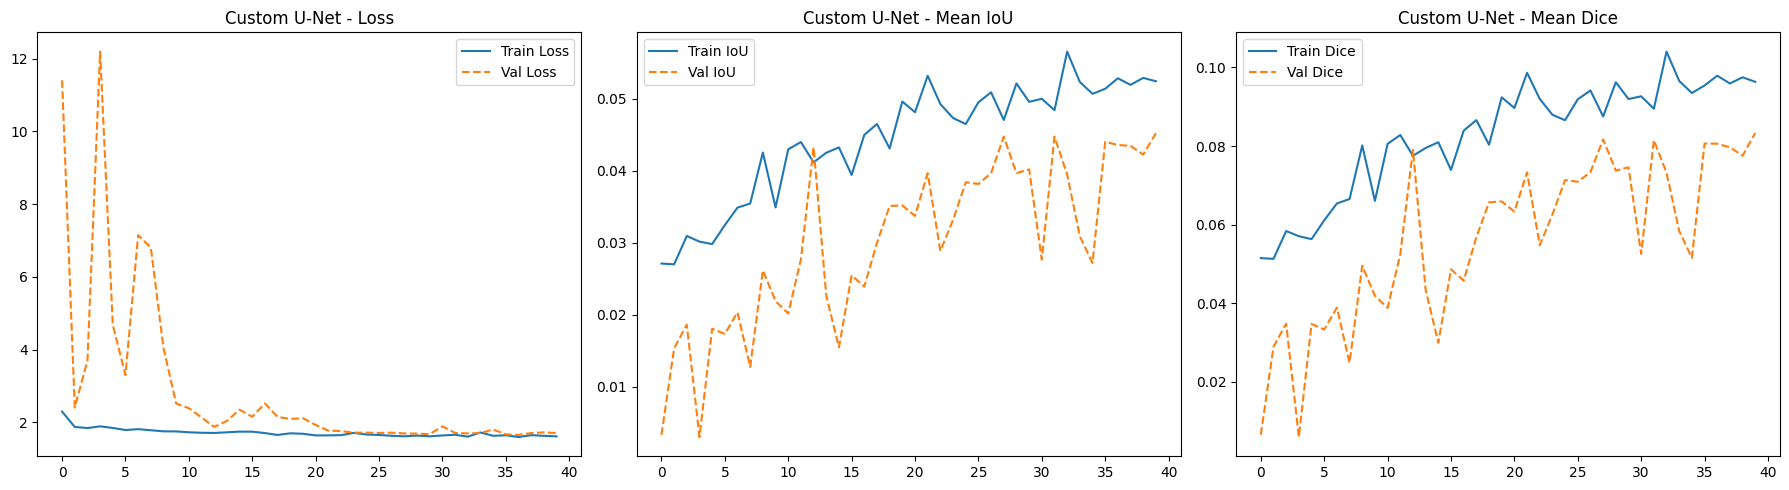

In [13]:
def plot_training_history(history_obj, model_name):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].plot(history_obj.history['loss'], label='Train Loss')
    axes[0].plot(history_obj.history['val_loss'], label='Val Loss', linestyle='--')
    axes[0].set_title(f'{model_name} - Loss')
    axes[0].legend()

    axes[1].plot(history_obj.history['mean_iou'], label='Train IoU')
    axes[1].plot(history_obj.history['val_mean_iou'], label='Val IoU', linestyle='--')
    axes[1].set_title(f'{model_name} - Mean IoU')
    axes[1].legend()

    axes[2].plot(history_obj.history['mean_dice'], label='Train Dice')
    axes[2].plot(history_obj.history['val_mean_dice'], label='Val Dice', linestyle='--')
    axes[2].set_title(f'{model_name} - Mean Dice')
    axes[2].legend()
    plt.tight_layout()
    plt.show()

plot_training_history(history, "Custom U-Net")

### **12. Pre-Trained MobileNetV2 Architecture**

In [14]:
def build_pretrained_unet(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    x = layers.Lambda(lambda img: (img * 2.0) - 1.0)(inputs) # MobileNet preprocessing

    base_model = tf.keras.applications.MobileNetV2(input_tensor=x, include_top=False, weights='imagenet')
    base_model.trainable = False

    s1 = inputs
    s2 = base_model.get_layer('block_1_expand_relu').output
    s3 = base_model.get_layer('block_3_expand_relu').output
    s4 = base_model.get_layer('block_6_expand_relu').output
    b1 = base_model.get_layer('block_13_expand_relu').output

    u4 = layers.Conv2DTranspose(192, 2, strides=2, padding="same")(b1)
    u4 = layers.concatenate([u4, s4])
    c4 = conv_block(u4, 192)

    u3 = layers.Conv2DTranspose(144, 2, strides=2, padding="same")(c4)
    u3 = layers.concatenate([u3, s3])
    c3 = conv_block(u3, 144)

    u2 = layers.Conv2DTranspose(96, 2, strides=2, padding="same")(c3)
    u2 = layers.concatenate([u2, s2])
    c2 = conv_block(u2, 96)

    u1 = layers.Conv2DTranspose(64, 2, strides=2, padding="same")(c2)
    u1 = layers.concatenate([u1, s1])
    c1 = conv_block(u1, 64)

    outputs = layers.Conv2D(num_classes, 1, activation="softmax")(c1)
    return models.Model(inputs, outputs, name="Pretrained_MobileNetV2_UNet")

pretrained_model = build_pretrained_unet((CONFIG["img_size"], CONFIG["img_size"], 3), CONFIG["num_classes"])
pretrained_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=CONFIG["learning_rate"]),
    loss=combined_focal_dice_loss(alpha=class_weights_array, gamma=2.0, focal_weight=0.5, dice_weight=1.5),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy"), MeanIoUMetric(num_classes=CONFIG["num_classes"]), MeanDiceMetric(num_classes=CONFIG["num_classes"])],
)

/tmp/ipykernel_5600/1555482099.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(input_tensor=x, include_top=False, weights='imagenet')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### **13. Training Pre-Trained Model**

Epoch 1/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.0880 - loss: 2.0323 - mean_dice: 0.0867 - mean_iou: 0.0475 - val_accuracy: 0.0566 - val_loss: 2.9769 - val_mean_dice: 0.0807 - val_mean_iou: 0.0455 - learning_rate: 0.0010
Epoch 2/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 438ms/step - accuracy: 0.0729 - loss: 1.6545 - mean_dice: 0.1024 - mean_iou: 0.0567 - val_accuracy: 0.0398 - val_loss: 6.7216 - val_mean_dice: 0.1282 - val_mean_iou: 0.0829 - learning_rate: 0.0010
Epoch 3/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 445ms/step - accuracy: 0.1482 - loss: 1.6093 - mean_dice: 0.1236 - mean_iou: 0.0699 - val_accuracy: 0.0581 - val_loss: 3.7668 - val_mean_dice: 0.1015 - val_mean_iou: 0.0591 - learning_rate: 0.0010
Epoch 4/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 415ms/step - accuracy: 0.1833 - loss: 1.6001 - mean_dice: 0.1063 - mean_iou: 0.0589 - val_accuracy: 0.0756 - val_loss: 1.9466 - val_mean_dice: 0.0714 - val_mean_iou: 0.0388 - learning_rate: 0.0010
Epoch 5/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 448ms/

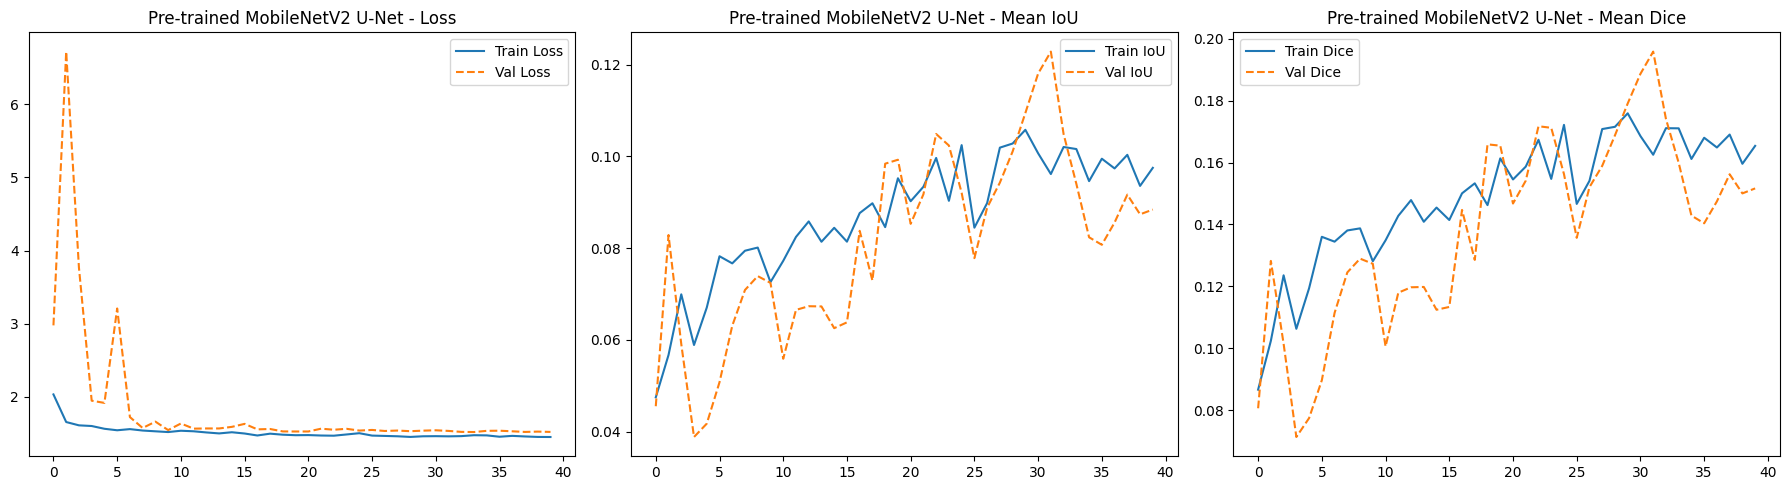

In [15]:
history_pretrained = pretrained_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=CONFIG["epochs"],
    callbacks=callbacks,
)
plot_training_history(history_pretrained, "Pre-trained MobileNetV2 U-Net")

### **14. Per-Class Evaluation Metrics**

In [16]:
def compute_per_class_iou(eval_model, generator, num_classes):
    total_cm = np.zeros((num_classes, num_classes), dtype=np.int64)

    for i in range(len(generator)):
        x, y = generator[i]
        preds = np.argmax(eval_model.predict(x, verbose=0), axis=-1)

        total_cm += confusion_matrix(y.flatten(), preds.flatten(), labels=list(range(num_classes)))

    ious = [(total_cm[c, c] / (total_cm[:, c].sum() + total_cm[c, :].sum() - total_cm[c, c] + 1e-7)) for c in range(num_classes)]
    return ious

custom_ious = compute_per_class_iou(model, val_gen, CONFIG["num_classes"])
pt_ious = compute_per_class_iou(pretrained_model, val_gen, CONFIG["num_classes"])

print("--- Per-Class IoU Breakdown (Validation Set) ---")
for i, class_name in enumerate(CONFIG["classes"]):
    print(f" - {class_name.ljust(12)} | Custom U-Net: {custom_ious[i]:.4f} | MobileNetV2: {pt_ious[i]:.4f}")

--- Per-Class IoU Breakdown (Validation Set) ---
 - background   | Custom U-Net: 0.0022 | MobileNetV2: 0.2216
 - person       | Custom U-Net: 0.0528 | MobileNetV2: 0.1613
 - car          | Custom U-Net: 0.1064 | MobileNetV2: 0.2013
 - book         | Custom U-Net: 0.0043 | MobileNetV2: 0.0102
 - airplane     | Custom U-Net: 0.0107 | MobileNetV2: 0.0033


### **15. Side-by-Side Visual Evaluation**

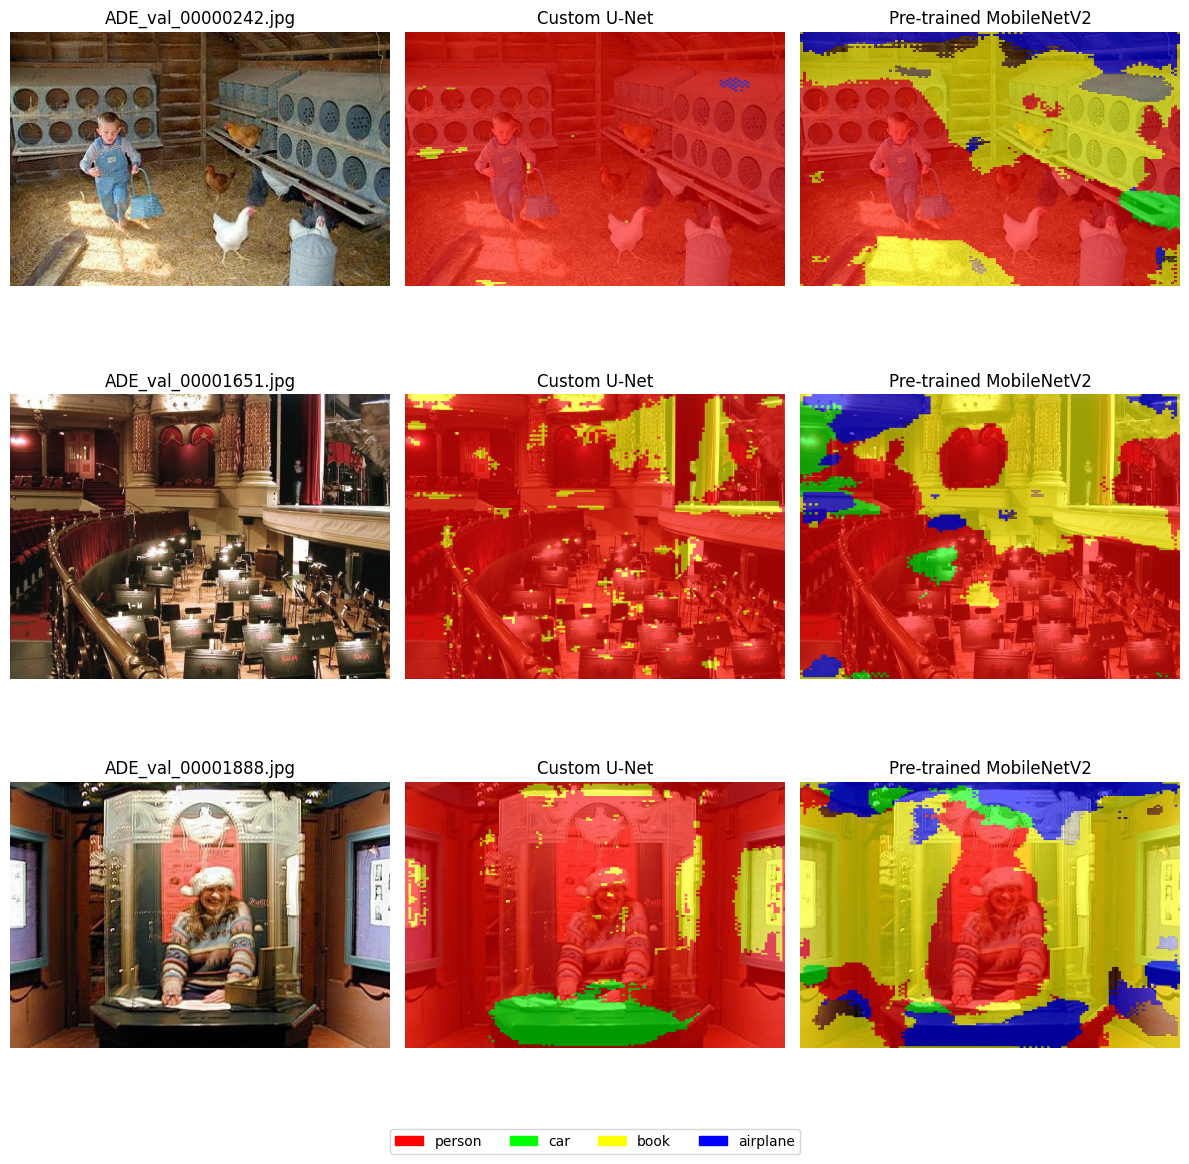

In [17]:
test_image_paths = glob.glob(os.path.join(TEST_IMG_DIR, "*.jpg"))[:3]
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for i, path in enumerate(test_image_paths):
    raw = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    resized = cv2.resize(raw, (CONFIG["img_size"], CONFIG["img_size"])) / 255.0
    img_tensor = np.expand_dims(resized, axis=0)

    pred_custom = np.argmax(model.predict(img_tensor, verbose=0)[0], axis=-1)
    pred_full_custom = cv2.resize(pred_custom.astype(np.uint8), (raw.shape[1], raw.shape[0]), interpolation=cv2.INTER_NEAREST)

    pred_pt = np.argmax(pretrained_model.predict(img_tensor, verbose=0)[0], axis=-1)
    pred_full_pt = cv2.resize(pred_pt.astype(np.uint8), (raw.shape[1], raw.shape[0]), interpolation=cv2.INTER_NEAREST)

    axes[i, 0].imshow(raw)
    axes[i, 0].set_title(os.path.basename(path))
    axes[i, 0].axis("off")

    axes[i, 1].imshow(raw)
    axes[i, 1].imshow(pred_full_custom, cmap=CMAP, norm=NORM, alpha=0.6)
    axes[i, 1].set_title("Custom U-Net")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(raw)
    axes[i, 2].imshow(pred_full_pt, cmap=CMAP, norm=NORM, alpha=0.6)
    axes[i, 2].set_title("Pre-trained MobileNetV2")
    axes[i, 2].axis("off")

handles = [plt.Rectangle((0, 0), 1, 1, color=CLASS_COLORS[c]) for c in CONFIG["classes"][1:]]
fig.legend(handles, CONFIG["classes"][1:], loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()